In [6]:
import tensorflow as tf
import numpy as np
import cv2
import os
import sys
import matplotlib.pyplot as plt

EPOCHS = 10
num_of_categories=43
IMG_WIDTH=30
IMG_HEIGHT=30

Visualize the first layer of the CNN

In [4]:
def feature_map_to_image(feature_map):
    '''
    reverse the normalization
    '''
    normalized = cv2.normalize(feature_map, None, 0, 255, cv2.NORM_MINMAX)
    return normalized.astype(np.uint8)

c:\Users\smile\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 31 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


image generated.


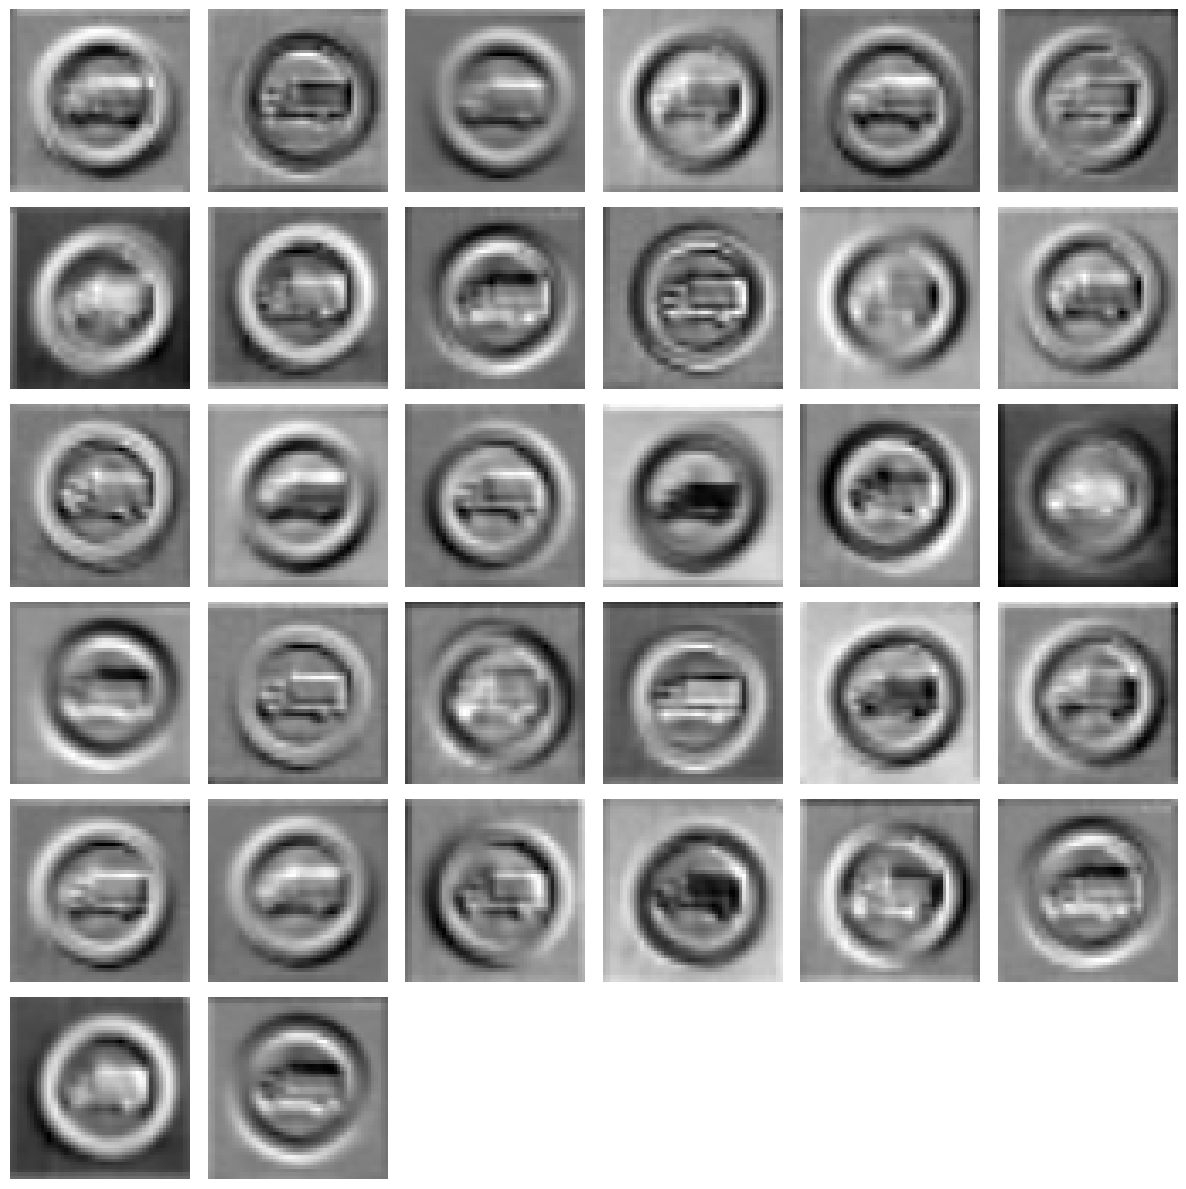

In [7]:
def kernel_visualization(img_path):
    '''
    load a good model and visualize its first layer given a manual input of some picture
    '''
    # load the model
    model = tf.keras.models.load_model("model.keras")
    
    # manually feed a chosen image into the CNN
    img = cv2.imread(img_path)
    height,width,channel=img.shape

    # resize so that they can be processed by the first Conv layer
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    train = np.load("train.npz")
    x_train = train["X"]
    x_train_mean, x_train_std = np.mean(x_train, axis=0), np.std(x_train, axis=0)
    
    img = np.array(img)-x_train_mean
    img_array = (img - x_train_mean) / x_train_std


    # Use zero padding to preserve the input size in the output array
    padded_img = np.pad(img_array, 
                        pad_width=((1, 1), (1, 1), (0, 0)), 
                        mode='constant', constant_values=0)

    # Look at the first layer filters
    filters, bias = model.layers[0].get_weights()
    num_of_filters = filters.shape[-1]

    # record the output
    V = np.zeros((IMG_WIDTH, IMG_HEIGHT, num_of_filters))
    for k in range(32):
        for i in range(30):
            for j in range(30):
               V[i,j,k] = np.sum(padded_img[i:i+3,j:j+3,:] * filters[:,:,:,k]) + bias[k]
    V = cv2.resize(V, (width, height))

    imgs = []

    for i in range(num_of_filters):
        fmap = V[:, :, i]
        image_array = feature_map_to_image(fmap)
        # as the output numpy array is only 2D for each filter, make R=G=B to create a grey image
        grey_img = np.stack([image_array]*3, axis=-1)
        imgs.append(grey_img)
        output_folder="results/A visualization"
        os.makedirs(output_folder, exist_ok=True)
        file_name=f"feature_map_{i}.png"
        output_path=os.path.join(output_folder, file_name)
        cv2.imwrite(output_path, grey_img)
    print("image generated.")

    num_images = num_of_filters
    cols = 6                                   # number of columns in grid
    rows = int(np.ceil(num_images / cols))     # rows needed

    plt.figure(figsize=(12, 12))

    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(imgs[i], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# first picture in the test set
kernel_visualization("data/Test/00000.png")

Observe that almost all filter pay attention to the contour circle of the traffic sign, but they focus on different fine-grained patterns inside the sign.